# eBird Basic Dataset — Análisis Exploratorio
**Condado:** Tuscaloosa, Alabama (US-AL-125)  
**Período:** Marzo 2025  
**Fuente:** eBird Basic Dataset, versión EBD_relMar-2025. Cornell Lab of Ornithology.

Este notebook explora los datos de observaciones de aves del EBD, incluyendo:
- Resumen general del dataset
- Especies más observadas
- Patrones temporales y horarios
- Protocolos de muestreo
- Mapa de localidades

In [17]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from pathlib import Path

# Elimina emojis y caracteres fuera del BMP que matplotlib no puede renderizar
_EMOJI_RE = re.compile(r'[\U00010000-\U0010FFFF]', flags=re.UNICODE)
def strip_emoji(text: str) -> str:
    return _EMOJI_RE.sub('', str(text)).strip()

# Configuración de estilo
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR = Path('../')

EBD_FILE = DATA_DIR / 'ebd_US-AL-125_202503_202503_smp_relMar-2025.txt'
SAMPLING_FILE = DATA_DIR / 'ebd_US-AL-125_202503_202503_smp_relMar-2025_sampling.txt'

print('Archivos encontrados:')
print(f'  EBD:      {EBD_FILE.exists()} — {EBD_FILE.name}')
print(f'  Sampling: {SAMPLING_FILE.exists()} — {SAMPLING_FILE.name}')

Archivos encontrados:
  EBD:      True — ebd_US-AL-125_202503_202503_smp_relMar-2025.txt
  Sampling: True — ebd_US-AL-125_202503_202503_smp_relMar-2025_sampling.txt


## 1. Carga de datos

In [18]:
# Columnas útiles del archivo de observaciones
OBS_COLS = [
    'GLOBAL UNIQUE IDENTIFIER', 'COMMON NAME', 'SCIENTIFIC NAME',
    'OBSERVATION COUNT', 'COUNTRY CODE', 'STATE CODE', 'COUNTY CODE',
    'LOCALITY', 'LOCALITY ID', 'LOCALITY TYPE', 'LATITUDE', 'LONGITUDE',
    'OBSERVATION DATE', 'TIME OBSERVATIONS STARTED', 'OBSERVER ID',
    'SAMPLING EVENT IDENTIFIER', 'PROTOCOL NAME', 'DURATION MINUTES',
    'EFFORT DISTANCE KM', 'NUMBER OBSERVERS', 'ALL SPECIES REPORTED',
    'HAS MEDIA', 'APPROVED'
]

obs = pd.read_csv(
    EBD_FILE,
    sep='\t',
    usecols=lambda c: c in OBS_COLS,
    low_memory=False
)

sampling = pd.read_csv(SAMPLING_FILE, sep='\t', low_memory=False)

# Conversiones de tipo
obs['OBSERVATION DATE'] = pd.to_datetime(obs['OBSERVATION DATE'])
obs['OBSERVATION COUNT'] = pd.to_numeric(obs['OBSERVATION COUNT'], errors='coerce')
sampling['OBSERVATION DATE'] = pd.to_datetime(sampling['OBSERVATION DATE'])

print(f'Observaciones cargadas:  {len(obs):,} filas × {obs.shape[1]} columnas')
print(f'Checklists (sampling):   {len(sampling):,} filas × {sampling.shape[1]} columnas')
obs.head(3)

Observaciones cargadas:  4,863 filas × 23 columnas
Checklists (sampling):   317 filas × 34 columnas


,GLOBAL UNIQUE IDENTIFIER,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,COUNTRY CODE,STATE CODE,COUNTY CODE,LOCALITY,LOCALITY ID,LOCALITY TYPE,...,TIME OBSERVATIONS STARTED,OBSERVER ID,SAMPLING EVENT IDENTIFIER,PROTOCOL NAME,DURATION MINUTES,EFFORT DISTANCE KM,NUMBER OBSERVERS,ALL SPECIES REPORTED,HAS MEDIA,APPROVED
0,URN:CornellLabOfOrnithology:EBIRD:OBS2919749158,American Crow,Corvus brachyrhynchos,2.0,US,US-AL,US-AL-125,"Lakefield Drive, Tuscaloosa",L10510092,H,...,06:21:00,obsr1073731,S215984764,Traveling,24.0,1.092,2.0,1,0,1
1,URN:CornellLabOfOrnithology:EBIRD:OBS2933256785,American Crow,Corvus brachyrhynchos,1.0,US,US-AL,US-AL-125,"23rd Street Area, Tuscaloosa",L12228602,P,...,06:27:00,obsr451424,S216708215,Stationary,15.0,NaN,1.0,1,0,1
2,URN:CornellLabOfOrnithology:EBIRD:OBS3009418896,American Crow,Corvus brachyrhynchos,3.0,US,US-AL,US-AL-125,River Bend Turf,L5039140,H,...,15:11:00,obsr451424,S221934152,Traveling,60.0,13.532,2.0,1,0,1


## 2. Resumen general

In [19]:
n_species = obs['COMMON NAME'].nunique()
n_checklists = obs['SAMPLING EVENT IDENTIFIER'].nunique()
n_observers = obs['OBSERVER ID'].nunique()
n_localities = obs['LOCALITY ID'].nunique()
date_range = f"{obs['OBSERVATION DATE'].min().date()} → {obs['OBSERVATION DATE'].max().date()}"

print('=' * 45)
print('  RESUMEN DEL DATASET')
print('=' * 45)
print(f'  Especies registradas : {n_species}')
print(f'  Checklists           : {n_checklists}')
print(f'  Observadores únicos  : {n_observers}')
print(f'  Localidades          : {n_localities}')
print(f'  Período              : {date_range}')
print('=' * 45)

  RESUMEN DEL DATASET
  Especies registradas : 125
  Checklists           : 313
  Observadores únicos  : 59
  Localidades          : 106
  Período              : 2025-03-01 → 2025-03-31


## 3. Especies más frecuentes
Frecuencia de reporte: porcentaje de checklists en que aparece cada especie (más informativo que el conteo bruto).

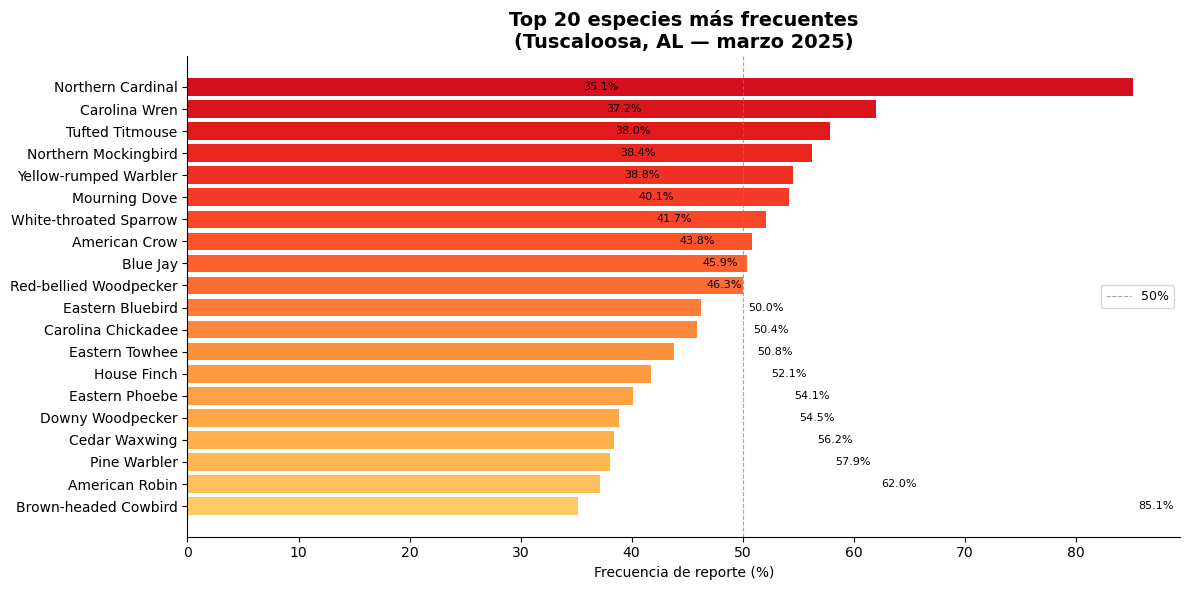

In [20]:
# Solo checklists completos (ALL SPECIES REPORTED = 1)
complete = obs[obs['ALL SPECIES REPORTED'] == 1].copy()
total_complete = complete['SAMPLING EVENT IDENTIFIER'].nunique()

freq = (
    complete.groupby('COMMON NAME')['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .div(total_complete)
    .mul(100)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.YlOrRd(np.linspace(0.8, 0.3, len(freq)))
bars = ax.barh(freq.index[::-1], freq.values[::-1], color=colors[::-1])
ax.set_xlabel('Frecuencia de reporte (%)')
ax.set_title('Top 20 especies más frecuentes\n(Tuscaloosa, AL — marzo 2025)', fontsize=14, fontweight='bold')
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='50%')
ax.legend(fontsize=9)
for bar, val in zip(bars[::-1], freq.values[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Actividad diaria — número de checklists por día

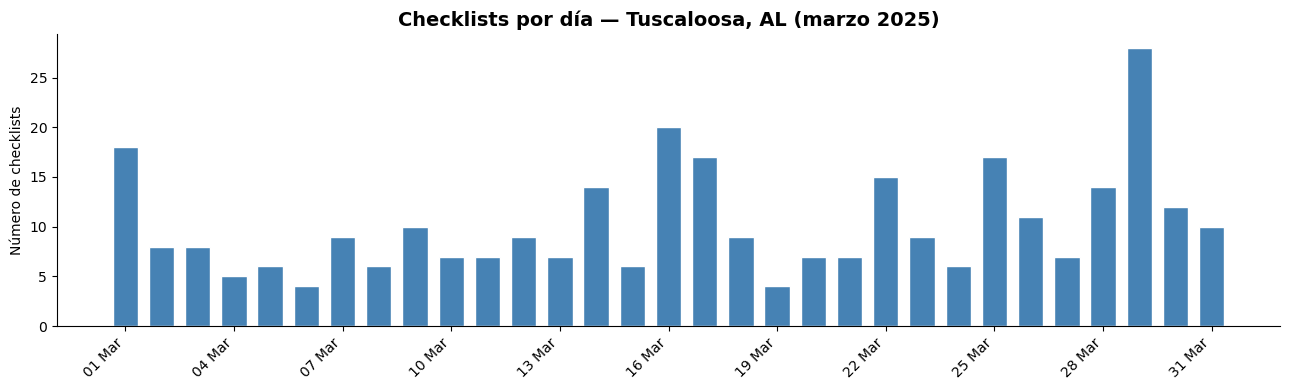

In [21]:
daily = (
    sampling.groupby('OBSERVATION DATE')
    .size()
    .rename('checklists')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(daily['OBSERVATION DATE'], daily['checklists'],
       color='steelblue', width=0.7, edgecolor='white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.set_ylabel('Número de checklists')
ax.set_title('Checklists por día — Tuscaloosa, AL (marzo 2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Distribución horaria de las salidas

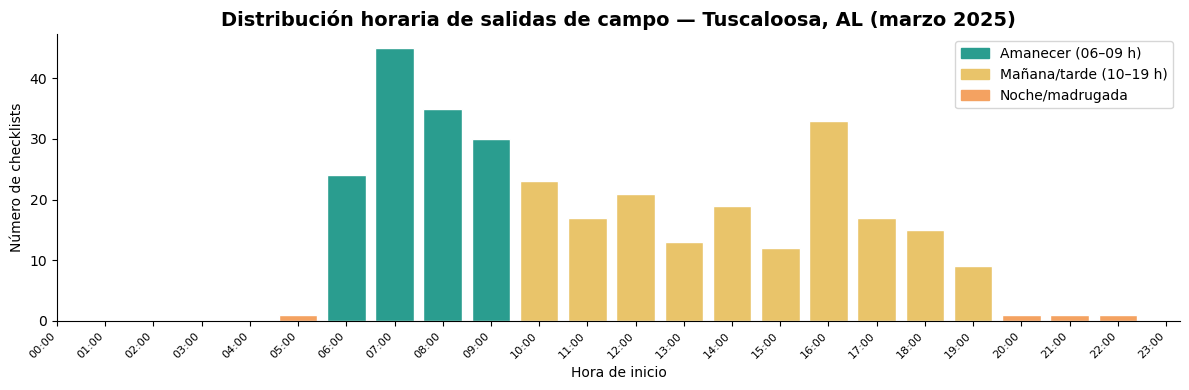

In [22]:
sampling_clean = sampling.dropna(subset=['TIME OBSERVATIONS STARTED']).copy()
sampling_clean['hour'] = pd.to_datetime(
    sampling_clean['TIME OBSERVATIONS STARTED'], format='%H:%M:%S', errors='coerce'
).dt.hour

hour_counts = sampling_clean['hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
bar_colors = ['#f4a261' if h < 6 or h >= 20 else '#2a9d8f' if h < 10 else '#e9c46a' for h in hour_counts.index]
ax.bar(hour_counts.index, hour_counts.values, color=bar_colors, edgecolor='white')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Hora de inicio')
ax.set_ylabel('Número de checklists')
ax.set_title('Distribución horaria de salidas de campo — Tuscaloosa, AL (marzo 2025)',
             fontsize=14, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2a9d8f', label='Amanecer (06–09 h)'),
    Patch(color='#e9c46a', label='Mañana/tarde (10–19 h)'),
    Patch(color='#f4a261', label='Noche/madrugada'),
])
plt.tight_layout()
plt.show()

## 6. Protocolos de muestreo

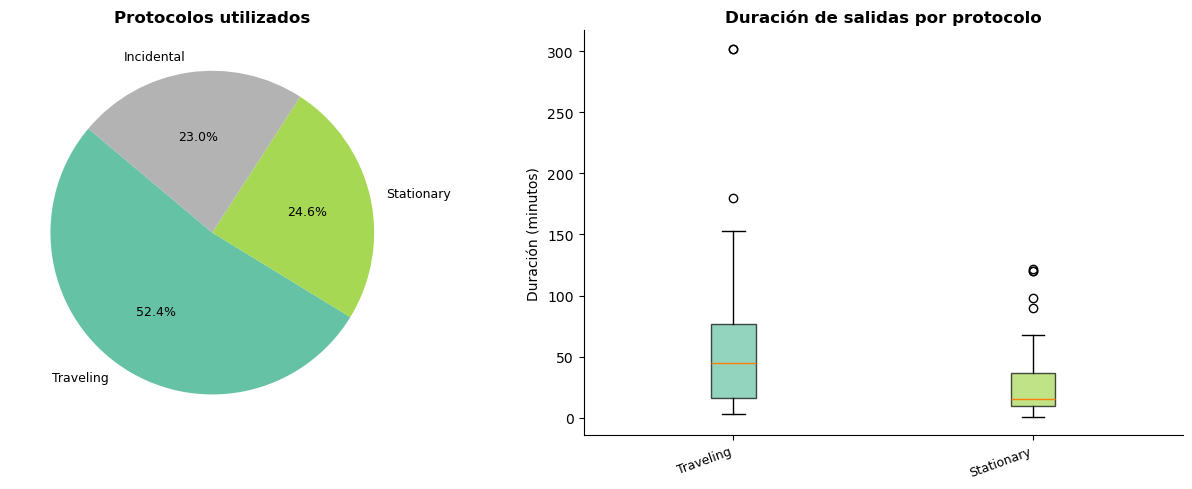

In [23]:
protocol_counts = sampling['PROTOCOL NAME'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
wedge_colors = plt.cm.Set2(np.linspace(0, 1, len(protocol_counts)))
axes[0].pie(protocol_counts.values, labels=protocol_counts.index,
            autopct='%1.1f%%', colors=wedge_colors, startangle=140,
            textprops={'fontsize': 9})
axes[0].set_title('Protocolos utilizados', fontsize=12, fontweight='bold')

# Duración por protocolo (boxplot)
dur = sampling.dropna(subset=['DURATION MINUTES', 'PROTOCOL NAME'])
protocols = dur['PROTOCOL NAME'].unique()
data_by_proto = [dur[dur['PROTOCOL NAME'] == p]['DURATION MINUTES'].values for p in protocols]
bp = axes[1].boxplot(data_by_proto, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], wedge_colors[:len(protocols)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xticks(range(1, len(protocols) + 1))
axes[1].set_xticklabels(protocols, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Duración (minutos)')
axes[1].set_title('Duración de salidas por protocolo', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Riqueza de especies por localidad (top 15)

C:\Users\usuario\AppData\Local\Temp\ipykernel_6924\1008367920.py:18: UserWarning: Glyph 127969 (\N{HOUSE WITH GARDEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\usuario\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127969 (\N{HOUSE WITH GARDEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


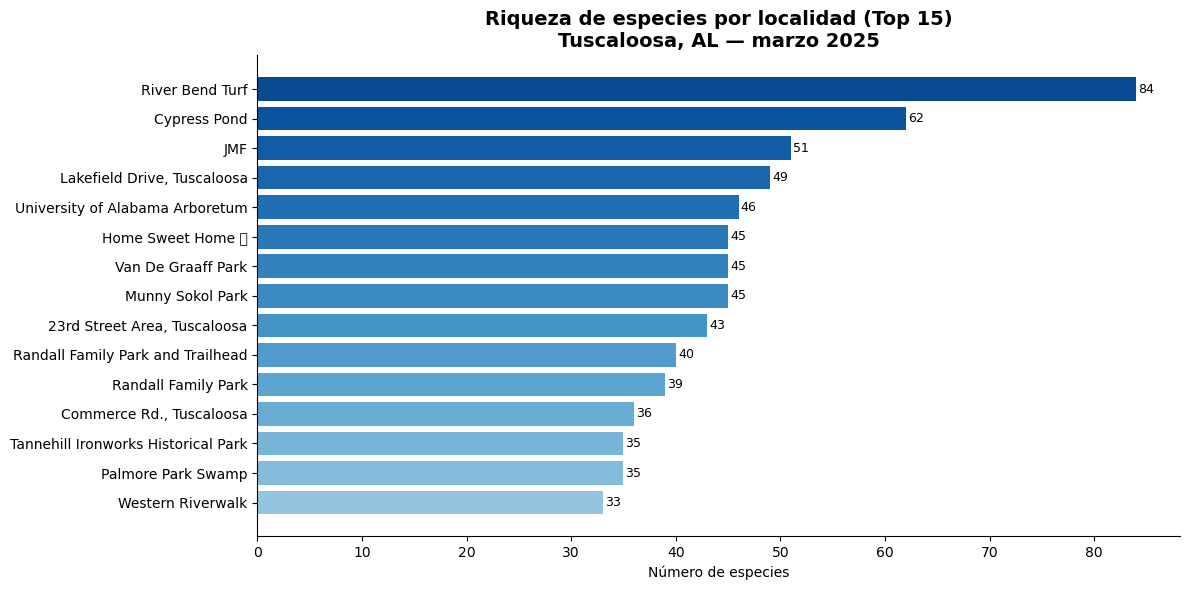

In [24]:
richness = (
    complete.groupby(['LOCALITY', 'LOCALITY ID'])
    ['COMMON NAME'].nunique()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(richness)))
bars = ax.barh(richness['LOCALITY'][::-1], richness['COMMON NAME'][::-1], color=colors)
ax.set_xlabel('Número de especies')
ax.set_title('Riqueza de especies por localidad (Top 15)\nTuscaloosa, AL — marzo 2025',
             fontsize=14, fontweight='bold')
for bar, val in zip(bars, richness['COMMON NAME'][::-1]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Mapa de localidades
Requiere `folium`. Se puede instalar con `pip install folium`.

folium no está instalado. Ejecuta: pip install folium
Mostrando mapa estático con matplotlib...


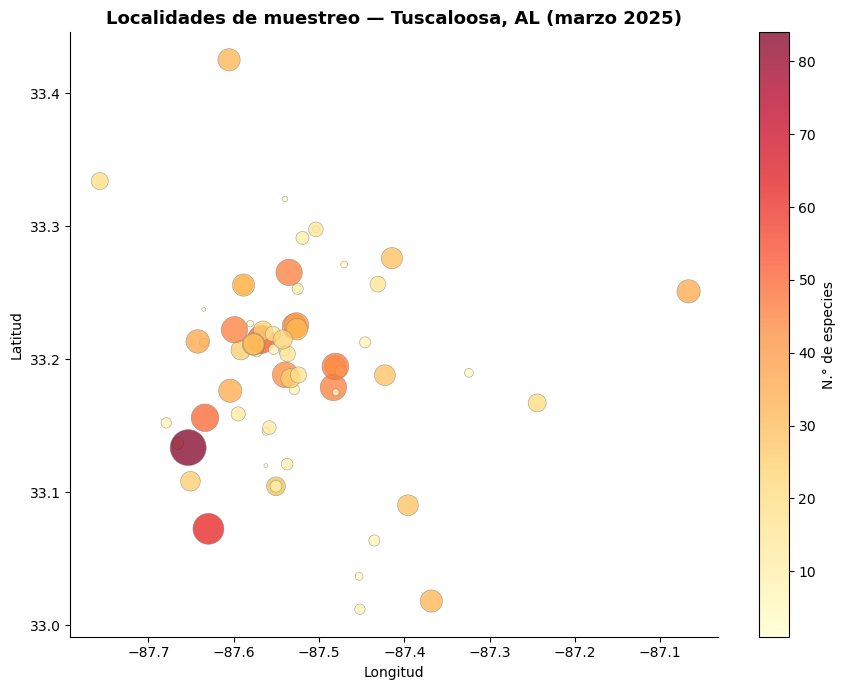

In [25]:
try:
    import folium

    loc_data = (
        complete.groupby(['LOCALITY', 'LOCALITY ID', 'LATITUDE', 'LONGITUDE'])
        .agg(
            especies=('COMMON NAME', 'nunique'),
            checklists=('SAMPLING EVENT IDENTIFIER', 'nunique')
        )
        .reset_index()
    )

    center = [loc_data['LATITUDE'].mean(), loc_data['LONGITUDE'].mean()]
    m = folium.Map(location=center, zoom_start=11, tiles='CartoDB positron')

    for _, row in loc_data.iterrows():
        folium.CircleMarker(
            location=[row['LATITUDE'], row['LONGITUDE']],
            radius=4 + row['especies'] * 0.25,
            color='#2a9d8f',
            fill=True,
            fill_color='#2a9d8f',
            fill_opacity=0.65,
            tooltip=(
                f"<b>{row['LOCALITY']}</b><br>"
                f"Especies: {row['especies']}<br>"
                f"Checklists: {row['checklists']}"
            )
        ).add_to(m)

    map_path = Path('ebd_localities_map.html')
    m.save(map_path)
    print(f'Mapa guardado en: {map_path.resolve()}')
    display(m)

except ImportError:
    print('folium no está instalado. Ejecuta: pip install folium')
    print('Mostrando mapa estático con matplotlib...')

    loc_data = (
        complete.groupby(['LOCALITY', 'LOCALITY ID', 'LATITUDE', 'LONGITUDE'])
        .agg(especies=('COMMON NAME', 'nunique'))
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(
        loc_data['LONGITUDE'], loc_data['LATITUDE'],
        s=loc_data['especies'] * 8, c=loc_data['especies'],
        cmap='YlOrRd', alpha=0.75, edgecolors='gray', linewidths=0.4
    )
    plt.colorbar(sc, ax=ax, label='N.° de especies')
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.set_title('Localidades de muestreo — Tuscaloosa, AL (marzo 2025)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9. Tabla resumen de especies observadas

In [26]:
species_summary = (
    obs.groupby(['COMMON NAME', 'SCIENTIFIC NAME'])
    .agg(
        checklists=('SAMPLING EVENT IDENTIFIER', 'nunique'),
        max_count=('OBSERVATION COUNT', 'max'),
        mean_count=('OBSERVATION COUNT', 'mean'),
        con_media=('HAS MEDIA', 'sum'),
    )
    .reset_index()
    .sort_values('checklists', ascending=False)
)

species_summary['freq_%'] = (species_summary['checklists'] / n_checklists * 100).round(1)
species_summary['mean_count'] = species_summary['mean_count'].round(2)

print(f'Total de especies: {len(species_summary)}')
species_summary.head(20)

Total de especies: 125


,COMMON NAME,SCIENTIFIC NAME,checklists,max_count,mean_count,con_media,freq_%
68,Northern Cardinal,Cardinalis cardinalis,232,30.0,5.40,0,74.1
29,Carolina Wren,Thryothorus ludovicianus,171,9.0,2.44,0,54.6
72,Northern Mockingbird,Mimus polyglottos,160,21.0,3.04,2,51.1
106,Tufted Titmouse,Baeolophus bicolor,157,15.0,3.48,0,50.2
66,Mourning Dove,Zenaida macroura,150,35.0,4.31,0,47.9
119,Yellow-rumped Warbler,Setophaga coronata,145,50.0,6.81,0,46.3
1,American Crow,Corvus brachyrhynchos,145,50.0,3.74,0,46.3
113,White-throated Sparrow,Zonotrichia albicollis,142,18.0,3.55,1,45.4
15,Blue Jay,Cyanocitta cristata,130,8.0,3.06,0,41.5
86,Red-bellied Woodpecker,Melanerpes carolinus,130,7.0,1.91,0,41.5


## 10. Estadísticas descriptivas por tipo de variable

### Variables categóricas: Especie (`COMMON NAME`) y Localidad (`LOCALITY`)
### Variable numérica: Cantidad observada (`OBSERVATION COUNT`)

In [27]:
## --- Variable numérica: OBSERVATION COUNT ---

obs_num = obs['OBSERVATION COUNT'].dropna()

media = obs_num.mean()
mediana = obs_num.median()
moda_val = obs_num.mode()
q1_obs = obs_num.quantile(0.25)
q3_obs = obs_num.quantile(0.75)
iqr_obs = q3_obs - q1_obs

print('=' * 50)
print('  OBSERVATION COUNT  (variable numérica)')
print('=' * 50)
print(f'  Media          : {media:.4f}')
print(f'  Mediana        : {mediana:.4f}')
print(f'  Moda           : {", ".join(str(v) for v in moda_val.values[:5])}')
print(f'  Q1 (25%)       : {q1_obs:.4f}')
print(f'  Q3 (75%)       : {q3_obs:.4f}')
print(f'  IQR (Q3 - Q1)  : {iqr_obs:.4f}')
print(f'  Min            : {obs_num.min():.0f}')
print(f'  Max            : {obs_num.max():.0f}')
print(f'  Desv. estándar : {obs_num.std():.4f}')
print(f'  N              : {len(obs_num):,}')
print()

## --- Variable categórica: COMMON NAME (Especie) ---

sp_counts = obs['COMMON NAME'].value_counts()

# Para variables categóricas:
#   Moda   = categoría más frecuente
#   Mediana categórica = categoría en la posición central del ranking de frecuencias
#   Media  = no aplica directamente; se usa la frecuencia media de aparición por especie

n_species_total = sp_counts.shape[0]
freq_media = sp_counts.mean()
freq_mediana_idx = n_species_total // 2
freq_mediana_cat = sp_counts.index[freq_mediana_idx]
freq_mediana_val = sp_counts.iloc[freq_mediana_idx]
moda_especie = sp_counts.index[0]
moda_especie_freq = sp_counts.iloc[0]

print('=' * 50)
print('  COMMON NAME  (variable categórica — Especie)')
print('=' * 50)
print(f'  N.° categorías distintas : {n_species_total}')
print(f'  Moda (más frecuente)     : {moda_especie}  ({moda_especie_freq} registros)')
print(f'  Mediana categórica       : {freq_mediana_cat}  ({freq_mediana_val} registros)')
print(f'  Frec. media por especie  : {freq_media:.2f} registros/especie')
print(f'  (IQR de frecuencias)     : [{sp_counts.quantile(0.25):.1f}, {sp_counts.quantile(0.75):.1f}] registros')
print()

## --- Variable categórica: LOCALITY ---

locality_counts = obs['LOCALITY'].value_counts()

n_localities = locality_counts.shape[0]
freq_media_l = locality_counts.mean()
freq_mediana_l_idx = n_localities // 2
freq_mediana_l_cat = locality_counts.index[freq_mediana_l_idx]
freq_mediana_l_val = locality_counts.iloc[freq_mediana_l_idx]
moda_locality = locality_counts.index[0]
moda_locality_freq = locality_counts.iloc[0]

print('=' * 50)
print('  LOCALITY  (variable categórica — Localidad)')
print('=' * 50)
print(f'  N.° localidades distintas : {n_localities}')
print(f'  Moda (más frecuente)      : {moda_locality}  ({moda_locality_freq} registros)')
print(f'  Mediana categórica        : {freq_mediana_l_cat}  ({freq_mediana_l_val} registros)')
print(f'  Frec. media por localidad : {freq_media_l:.2f} registros/localidad')
print(f'  (IQR de frecuencias)      : [{locality_counts.quantile(0.25):.1f}, {locality_counts.quantile(0.75):.1f}] registros')


  OBSERVATION COUNT  (variable numérica)
  Media          : 5.3399
  Mediana        : 2.0000
  Moda           : 1.0
  Q1 (25%)       : 1.0000
  Q3 (75%)       : 4.0000
  IQR (Q3 - Q1)  : 3.0000
  Min            : 1
  Max            : 500
  Desv. estándar : 15.4345
  N              : 4,834

  COMMON NAME  (variable categórica — Especie)
  N.° categorías distintas : 125
  Moda (más frecuente)     : Northern Cardinal  (232 registros)
  Mediana categórica       : Black Vulture  (19 registros)
  Frec. media por especie  : 38.90 registros/especie
  (IQR de frecuencias)     : [5.0, 57.0] registros

  LOCALITY  (variable categórica — Localidad)
  N.° localidades distintas : 102
  Moda (más frecuente)      : River Bend Turf  (696 registros)
  Mediana categórica        : Newt Hinton Park  (9 registros)
  Frec. media por localidad : 47.68 registros/localidad
  (IQR de frecuencias)      : [2.0, 41.5] registros


C:\Users\usuario\AppData\Local\Temp\ipykernel_6924\544481018.py:37: UserWarning: Glyph 127969 (\N{HOUSE WITH GARDEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\usuario\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127969 (\N{HOUSE WITH GARDEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


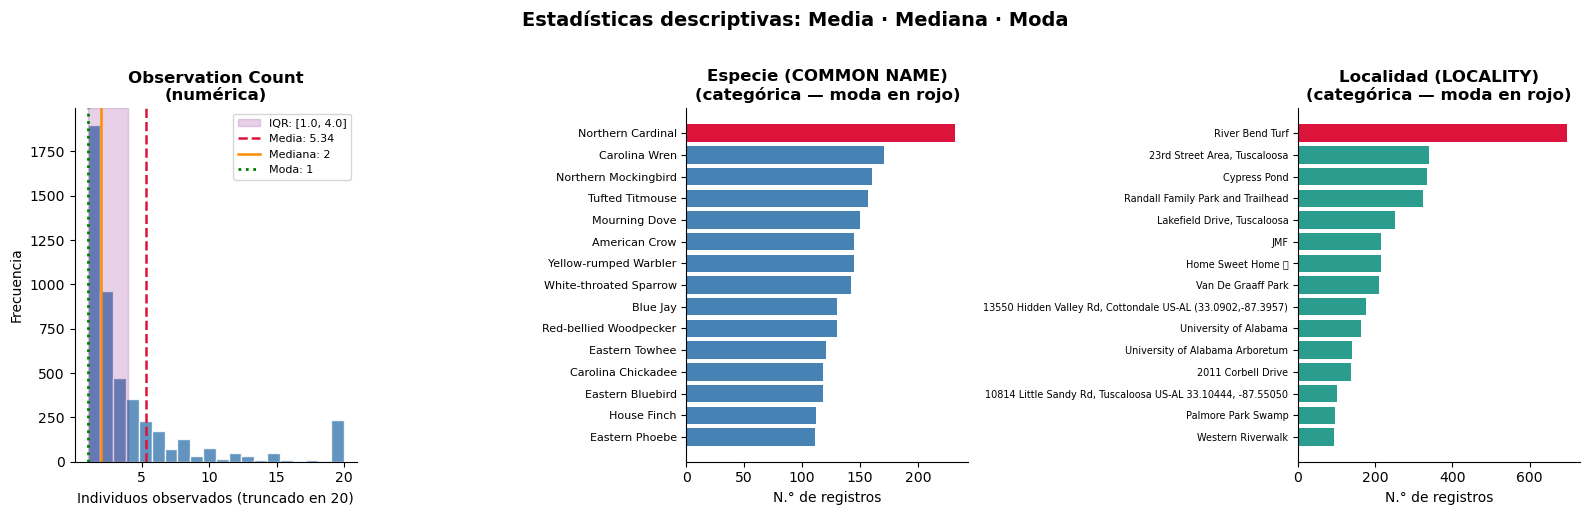

In [28]:
## Visualización comparativa

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- 1. Histograma OBSERVATION COUNT con banda IQR y líneas de media/mediana/moda ---
ax = axes[0]
ax.hist(obs_num.clip(upper=20), bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvspan(q1_obs, min(q3_obs, 20), alpha=0.18, color='purple',
           label=f'IQR: [{q1_obs:.1f}, {q3_obs:.1f}]')
ax.axvline(media, color='crimson', linestyle='--', linewidth=1.8, label=f'Media: {media:.2f}')
ax.axvline(mediana, color='darkorange', linestyle='-', linewidth=1.8, label=f'Mediana: {mediana:.0f}')
ax.axvline(moda_val.iloc[0], color='green', linestyle=':', linewidth=2, label=f'Moda: {moda_val.iloc[0]:.0f}')
ax.set_title('Observation Count\n(numérica)', fontsize=12, fontweight='bold')
ax.set_xlabel('Individuos observados (truncado en 20)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=8)

# --- 2. Barras top 15 especies (moda resaltada) ---
ax = axes[1]
top_sp = sp_counts.head(15)
colors_sp = ['crimson' if s == moda_especie else 'steelblue' for s in top_sp.index]
ax.barh(top_sp.index[::-1], top_sp.values[::-1], color=colors_sp[::-1])
ax.set_title('Especie (COMMON NAME)\n(categórica — moda en rojo)', fontsize=12, fontweight='bold')
ax.set_xlabel('N.° de registros')
ax.tick_params(axis='y', labelsize=8)

# --- 3. Barras top 15 localidades (moda resaltada) ---
ax = axes[2]
top_loc = locality_counts.head(15)
colors_l = ['crimson' if l == moda_locality else '#2a9d8f' for l in top_loc.index]
ax.barh(top_loc.index[::-1], top_loc.values[::-1], color=colors_l[::-1])
ax.set_title('Localidad (LOCALITY)\n(categórica — moda en rojo)', fontsize=12, fontweight='bold')
ax.set_xlabel('N.° de registros')
ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Estadísticas descriptivas: Media · Mediana · Moda', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 11. Estadísticas descriptivas: checklists por día y por hora

Análisis de la distribución de **checklists por día** y de los **horarios de salida agrupados por hora del día**.  
Se calculan: media, mediana, moda, varianza, desvío estándar, asimetría (skewness) y curtosis.

In [29]:
from scipy import stats as sp_stats

# ── 1. CHECKLISTS POR DÍA ─────────────────────────────────────────────────────
daily_counts = (
    sampling.groupby('OBSERVATION DATE')
    .size()
    .rename('checklists')
)

day_series = daily_counts.values.astype(float)

day_stats = {
    'Media'              : np.mean(day_series),
    'Mediana'            : np.median(day_series),
    'Moda'               : sp_stats.mode(day_series, keepdims=True).mode[0],
    'Q1 (25%)'           : np.percentile(day_series, 25),
    'Q3 (75%)'           : np.percentile(day_series, 75),
    'IQR (Q3-Q1)'        : np.percentile(day_series, 75) - np.percentile(day_series, 25),
    'Varianza'           : np.var(day_series, ddof=1),
    'Desvío estándar'    : np.std(day_series, ddof=1),
    'Asimetría (skew)'   : sp_stats.skew(day_series),
    'Curtosis (excess)'  : sp_stats.kurtosis(day_series),
}

print('=' * 52)
print('  CHECKLISTS POR DÍA')
print('=' * 52)
for k, v in day_stats.items():
    print(f'  {k:<22}: {v:.4f}')
print(f'  {"N (días)":<22}: {len(day_series)}')

# ── 2. CHECKLISTS POR HORA DEL DÍA ───────────────────────────────────────────
sampling_h = sampling.dropna(subset=['TIME OBSERVATIONS STARTED']).copy()
sampling_h['hour'] = pd.to_datetime(
    sampling_h['TIME OBSERVATIONS STARTED'], format='%H:%M:%S', errors='coerce'
).dt.hour

# Contar checklists por hora (frecuencia de cada slot horario)
hour_counts = sampling_h['hour'].value_counts().sort_index()

# Serie de horas de inicio (una por checklist) para las estadísticas de distribución
hour_series = sampling_h['hour'].dropna().values.astype(float)

hour_stats = {
    'Media'              : np.mean(hour_series),
    'Mediana'            : np.median(hour_series),
    'Moda'               : sp_stats.mode(hour_series, keepdims=True).mode[0],
    'Q1 (25%)'           : np.percentile(hour_series, 25),
    'Q3 (75%)'           : np.percentile(hour_series, 75),
    'IQR (Q3-Q1)'        : np.percentile(hour_series, 75) - np.percentile(hour_series, 25),
    'Varianza'           : np.var(hour_series, ddof=1),
    'Desvío estándar'    : np.std(hour_series, ddof=1),
    'Asimetría (skew)'   : sp_stats.skew(hour_series),
    'Curtosis (excess)'  : sp_stats.kurtosis(hour_series),
}

print()
print('=' * 52)
print('  HORA DE INICIO DE SALIDAS (distribución)')
print('=' * 52)
for k, v in hour_stats.items():
    print(f'  {k:<22}: {v:.4f}')
print(f'  {"N (checklists)":<22}: {len(hour_series)}')

# ── 3. TABLA: checklists por hora con estadísticos por slot ─────────────────
print()
print('=' * 52)
print('  CHECKLISTS POR HORA DEL DÍA (tabla)')
print('=' * 52)
print(f'  {"Hora":>4}  {"Checklists":>11}  {"% del total":>11}')
print('  ' + '-' * 32)
for h, cnt in hour_counts.items():
    pct = cnt / len(hour_series) * 100
    print(f'  {int(h):02d}:00  {cnt:>11}  {pct:>10.1f}%')
print('  ' + '-' * 32)
print(f'  Total  {len(hour_series):>11}  {"100.0%":>11}')


  CHECKLISTS POR DÍA
  Media                 : 10.2258
  Mediana               : 9.0000
  Moda                  : 7.0000
  Q1 (25%)              : 7.0000
  Q3 (75%)              : 13.0000
  IQR (Q3-Q1)           : 6.0000
  Varianza              : 29.1140
  Desvío estándar       : 5.3957
  Asimetría (skew)      : 1.4463
  Curtosis (excess)     : 2.0173
  N (días)              : 31

  HORA DE INICIO DE SALIDAS (distribución)
  Media                 : 11.4164
  Mediana               : 11.0000
  Moda                  : 7.0000
  Q1 (25%)              : 8.0000
  Q3 (75%)              : 15.0000
  IQR (Q3-Q1)           : 7.0000
  Varianza              : 16.5982
  Desvío estándar       : 4.0741
  Asimetría (skew)      : 0.3814
  Curtosis (excess)     : -1.1136
  N (checklists)        : 317

  CHECKLISTS POR HORA DEL DÍA (tabla)
  Hora   Checklists  % del total
  --------------------------------
  05:00            1         0.3%
  06:00           24         7.6%
  07:00           45        14.2%

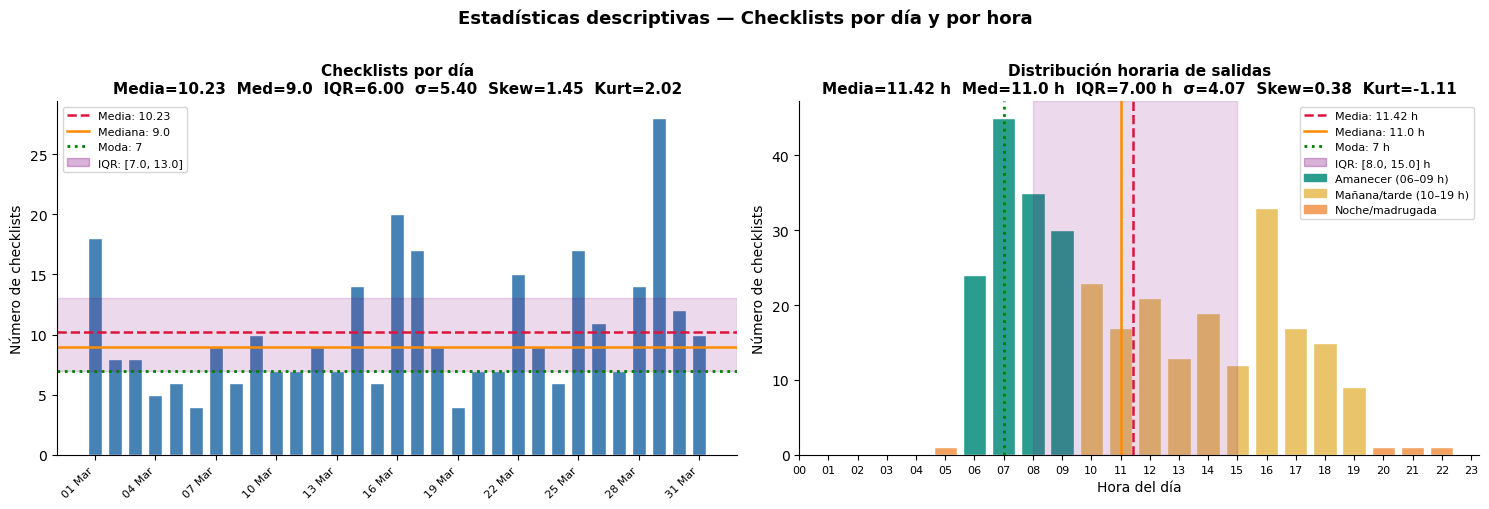

In [30]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel izquierdo: checklists por día ──────────────────────────────────────
ax = axes[0]
ax.bar(daily_counts.index, daily_counts.values, color='steelblue',
       edgecolor='white', width=0.7)
ax.axhspan(day_stats['Q1 (25%)'], day_stats['Q3 (75%)'], alpha=0.15, color='purple')
ax.axhline(day_stats['Media'],    color='crimson',    linestyle='--', linewidth=1.8)
ax.axhline(day_stats['Mediana'],  color='darkorange',  linestyle='-',  linewidth=1.8)
ax.axhline(day_stats['Moda'],     color='green',       linestyle=':',  linewidth=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Número de checklists')
ax.set_title(
    f'Checklists por día\n'
    f'Media={day_stats["Media"]:.2f}  Med={day_stats["Mediana"]:.1f}  '
    f'IQR={day_stats["IQR (Q3-Q1)"]:.2f}  '
    f'σ={day_stats["Desvío estándar"]:.2f}  '
    f'Skew={day_stats["Asimetría (skew)"]:.2f}  '
    f'Kurt={day_stats["Curtosis (excess)"]:.2f}',
    fontsize=11, fontweight='bold'
)
ax.legend(handles=[
    Line2D([0], [0], color='crimson', linestyle='--', linewidth=1.8,
           label=f"Media: {day_stats['Media']:.2f}"),
    Line2D([0], [0], color='darkorange', linestyle='-', linewidth=1.8,
           label=f"Mediana: {day_stats['Mediana']:.1f}"),
    Line2D([0], [0], color='green', linestyle=':', linewidth=2,
           label=f"Moda: {day_stats['Moda']:.0f}"),
    Patch(color='purple', alpha=0.3,
          label=f"IQR: [{day_stats['Q1 (25%)']:.1f}, {day_stats['Q3 (75%)']:.1f}]"),
], fontsize=8)

# ── Panel derecho: distribución horaria ──────────────────────────────────────
ax = axes[1]
bar_colors = [
    '#f4a261' if h < 6 or h >= 20
    else '#2a9d8f' if h < 10
    else '#e9c46a'
    for h in hour_counts.index
]
ax.bar(hour_counts.index, hour_counts.values, color=bar_colors, edgecolor='white')
ax.axvspan(hour_stats['Q1 (25%)'], hour_stats['Q3 (75%)'], alpha=0.15, color='purple')
ax.axvline(hour_stats['Media'],   color='crimson',   linestyle='--', linewidth=1.8)
ax.axvline(hour_stats['Mediana'], color='darkorange', linestyle='-',  linewidth=1.8)
ax.axvline(hour_stats['Moda'],    color='green',      linestyle=':',  linewidth=2)
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)], fontsize=8)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Número de checklists')
ax.set_title(
    f'Distribución horaria de salidas\n'
    f'Media={hour_stats["Media"]:.2f} h  Med={hour_stats["Mediana"]:.1f} h  '
    f'IQR={hour_stats["IQR (Q3-Q1)"]:.2f} h  '
    f'σ={hour_stats["Desvío estándar"]:.2f}  '
    f'Skew={hour_stats["Asimetría (skew)"]:.2f}  '
    f'Kurt={hour_stats["Curtosis (excess)"]:.2f}',
    fontsize=11, fontweight='bold'
)
ax.legend(handles=[
    Line2D([0], [0], color='crimson', linestyle='--', linewidth=1.8,
           label=f"Media: {hour_stats['Media']:.2f} h"),
    Line2D([0], [0], color='darkorange', linestyle='-', linewidth=1.8,
           label=f"Mediana: {hour_stats['Mediana']:.1f} h"),
    Line2D([0], [0], color='green', linestyle=':', linewidth=2,
           label=f"Moda: {hour_stats['Moda']:.0f} h"),
    Patch(color='purple', alpha=0.3,
          label=f"IQR: [{hour_stats['Q1 (25%)']:.1f}, {hour_stats['Q3 (75%)']:.1f}] h"),
    Patch(color='#2a9d8f', label='Amanecer (06–09 h)'),
    Patch(color='#e9c46a', label='Mañana/tarde (10–19 h)'),
    Patch(color='#f4a261', label='Noche/madrugada'),
], fontsize=8)

plt.suptitle('Estadísticas descriptivas — Checklists por día y por hora',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 12. Estadísticas descriptivas: cantidad de observaciones por checklist

Para cada checklist (`SAMPLING EVENT IDENTIFIER`) se cuenta cuántos registros de especies contiene.
Se calculan: media, mediana, moda, varianza, desvío estándar, asimetría y curtosis.

In [31]:
from scipy import stats as sp_stats

# ── Observaciones por checklist ───────────────────────────────────────────────
obs_per_checklist = (
    obs.groupby('SAMPLING EVENT IDENTIFIER')
    .size()
    .rename('n_obs')
)

ops = obs_per_checklist.values.astype(float)

moda_res = sp_stats.mode(ops, keepdims=True)

obs_stats = {
    'Media'              : np.mean(ops),
    'Mediana'            : np.median(ops),
    'Moda'               : moda_res.mode[0],
    'Frec. de la moda'   : int(moda_res.count[0]),
    'Q1 (25%)'           : np.percentile(ops, 25),
    'Q3 (75%)'           : np.percentile(ops, 75),
    'IQR (Q3-Q1)'        : np.percentile(ops, 75) - np.percentile(ops, 25),
    'Varianza'           : np.var(ops, ddof=1),
    'Desvío estándar'    : np.std(ops, ddof=1),
    'Mínimo'             : ops.min(),
    'Máximo'             : ops.max(),
    'Asimetría (skew)'   : sp_stats.skew(ops),
    'Curtosis (excess)'  : sp_stats.kurtosis(ops),
}

print('=' * 56)
print('  OBSERVACIONES POR CHECKLIST (n especies por salida)')
print('=' * 56)
for k, v in obs_stats.items():
    if isinstance(v, float):
        print(f'  {k:<24}: {v:.4f}')
    else:
        print(f'  {k:<24}: {v}')
print(f'  {"N (checklists)":<24}: {len(ops):,}')

# ── Tabla de frecuencias por tramo (deciles) ──────────────────────────────────
print()
print('  Distribución por rango de obs/checklist:')
bins = [0, 5, 10, 15, 20, 30, 50, ops.max() + 1]
labels = ['1–5', '6–10', '11–15', '16–20', '21–30', '31–50', '>50']
cuts = pd.cut(obs_per_checklist, bins=bins, labels=labels, right=True)
freq_table = cuts.value_counts().sort_index()
print(f'  {"Rango":>8}  {"Checklists":>11}  {"% del total":>11}')
print('  ' + '-' * 36)
for rng, cnt in freq_table.items():
    pct = cnt / len(ops) * 100
    print(f'  {str(rng):>8}  {cnt:>11}  {pct:>10.1f}%')
print('  ' + '-' * 36)
print(f'  {"Total":>8}  {len(ops):>11}  {"100.0%":>11}')


  OBSERVACIONES POR CHECKLIST (n especies por salida)
  Media                   : 15.5367
  Mediana                 : 14.0000
  Moda                    : 1.0000
  Frec. de la moda        : 36
  Q1 (25%)                : 5.0000
  Q3 (75%)                : 23.0000
  IQR (Q3-Q1)             : 18.0000
  Varianza                : 145.5187
  Desvío estándar         : 12.0631
  Mínimo                  : 1.0000
  Máximo                  : 56.0000
  Asimetría (skew)        : 0.8785
  Curtosis (excess)       : 0.4432
  N (checklists)          : 313

  Distribución por rango de obs/checklist:
     Rango   Checklists  % del total
  ------------------------------------
       1–5           80        25.6%
      6–10           49        15.7%
     11–15           41        13.1%
     16–20           49        15.7%
     21–30           56        17.9%
     31–50           34        10.9%
       >50            4         1.3%
  ------------------------------------
     Total          313       100.0%


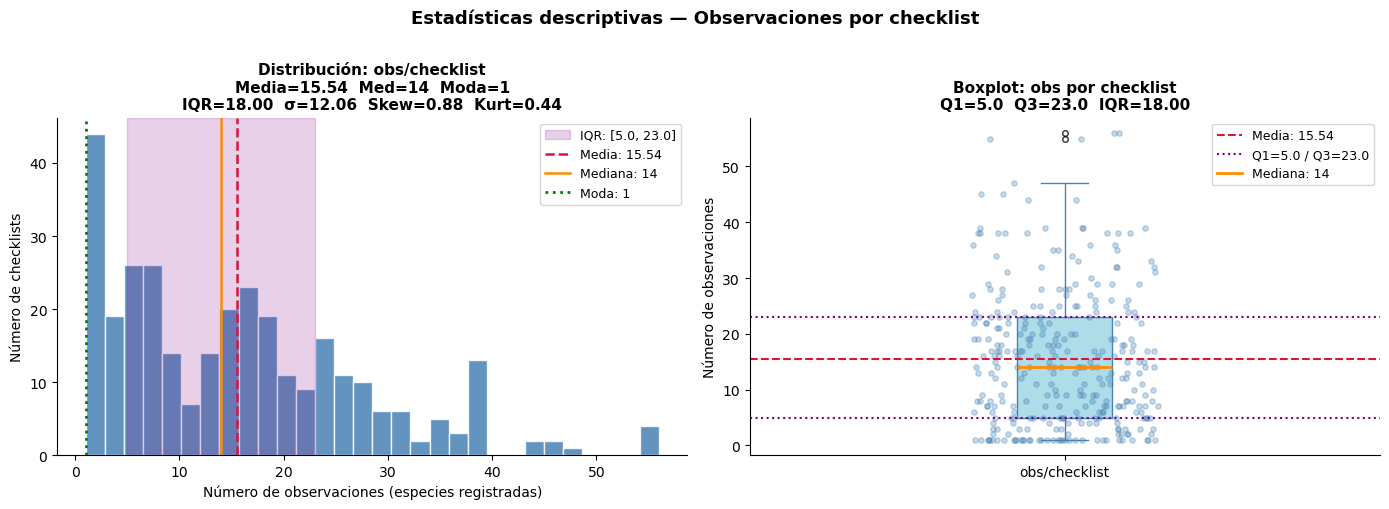

In [32]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

media_v    = obs_stats['Media']
mediana_v  = obs_stats['Mediana']
moda_v     = obs_stats['Moda']
std_v      = obs_stats['Desvío estándar']
skew_v     = obs_stats['Asimetría (skew)']
kurt_v     = obs_stats['Curtosis (excess)']
q1_v       = obs_stats['Q1 (25%)']
q3_v       = obs_stats['Q3 (75%)']
iqr_v      = obs_stats['IQR (Q3-Q1)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel izquierdo: histograma con banda IQR ─────────────────────────────────
ax = axes[0]
ax.hist(ops, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvspan(q1_v, q3_v, alpha=0.18, color='purple',
           label=f'IQR: [{q1_v:.1f}, {q3_v:.1f}]')
ax.axvline(media_v,   color='crimson',    linestyle='--', linewidth=1.8,
           label=f'Media: {media_v:.2f}')
ax.axvline(mediana_v, color='darkorange', linestyle='-',  linewidth=1.8,
           label=f'Mediana: {mediana_v:.0f}')
ax.axvline(moda_v,    color='green',      linestyle=':',  linewidth=2,
           label=f'Moda: {moda_v:.0f}')
ax.set_xlabel('Número de observaciones (especies registradas)')
ax.set_ylabel('Número de checklists')
ax.set_title(
    f'Distribución: obs/checklist\n'
    f'Media={media_v:.2f}  Med={mediana_v:.0f}  Moda={moda_v:.0f}\n'
    f'IQR={iqr_v:.2f}  σ={std_v:.2f}  Skew={skew_v:.2f}  Kurt={kurt_v:.2f}',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)

# ── Panel derecho: boxplot + strip con líneas Q1/Q3 ──────────────────────────
ax = axes[1]
bp = ax.boxplot(ops, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#aedce8', color='steelblue'),
                medianprops=dict(color='darkorange', linewidth=2),
                whiskerprops=dict(color='steelblue'),
                capprops=dict(color='steelblue'),
                flierprops=dict(marker='o', color='crimson', alpha=0.5, markersize=4))
# jitter
rng = np.random.default_rng(42)
jitter = rng.uniform(-0.15, 0.15, size=len(ops))
ax.scatter(1 + jitter, ops, alpha=0.3, s=15, color='steelblue', zorder=2)
ax.axhline(media_v, color='crimson',  linestyle='--', linewidth=1.5)
ax.axhline(q1_v,    color='purple',   linestyle=':',  linewidth=1.5)
ax.axhline(q3_v,    color='purple',   linestyle=':',  linewidth=1.5)
ax.set_xticks([1])
ax.set_xticklabels(['obs/checklist'])
ax.set_ylabel('Número de observaciones')
ax.set_title(
    f'Boxplot: obs por checklist\n'
    f'Q1={q1_v:.1f}  Q3={q3_v:.1f}  IQR={iqr_v:.2f}',
    fontsize=11, fontweight='bold'
)
ax.legend(handles=[
    Line2D([0], [0], color='crimson', linestyle='--', linewidth=1.5,
           label=f'Media: {media_v:.2f}'),
    Line2D([0], [0], color='purple', linestyle=':', linewidth=1.5,
           label=f'Q1={q1_v:.1f} / Q3={q3_v:.1f}'),
    Line2D([0], [0], color='darkorange', linestyle='-', linewidth=2,
           label=f'Mediana: {mediana_v:.0f}'),
], fontsize=9)

plt.suptitle('Estadísticas descriptivas — Observaciones por checklist',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 13. Correlaciones de Pearson, Spearman y Kendall

Análisis de correlación entre **checklists por día**, **cantidad observada media** (`OBSERVATION COUNT`) y **antigüedad media del checklist** (días entre `OBSERVATION DATE` y `LAST EDITED DATE`), agrupados por día (MM/YYYY).

In [ ]:
from scipy import stats as sp_stats

# ── 1. Construir serie diaria ─────────────────────────────────────────────────
sampling['LAST EDITED DATE'] = pd.to_datetime(sampling['LAST EDITED DATE'], errors='coerce')
sampling['age_days'] = (sampling['LAST EDITED DATE'] - sampling['OBSERVATION DATE']).dt.days

daily_corr = (
    sampling.groupby('OBSERVATION DATE')
    .agg(
        n_checklists=('SAMPLING EVENT IDENTIFIER', 'count'),
        age_media    =('age_days', 'mean'),
    )
    .reset_index()
)

obs_daily_mean = (
    obs.groupby('OBSERVATION DATE')['OBSERVATION COUNT']
    .mean()
    .rename('obs_count_media')
    .reset_index()
)

daily_corr = daily_corr.merge(obs_daily_mean, on='OBSERVATION DATE', how='left')
daily_corr['mm_yyyy'] = daily_corr['OBSERVATION DATE'].dt.strftime('%m/%Y')

# Codificación numérica de la fecha (días desde el primer día del dataset)
t0 = daily_corr['OBSERVATION DATE'].min()
daily_corr['dia_num'] = (daily_corr['OBSERVATION DATE'] - t0).dt.days

vars_corr = ['dia_num', 'n_checklists', 'obs_count_media', 'age_media']
labels_corr = ['Día (num)', 'Checklists/día', 'Obs. count media', 'Antigüedad media (días)']
data_corr = daily_corr[vars_corr].dropna()

# ── 2. Matrices de correlación ────────────────────────────────────────────────
def correlation_matrix(df, method):
    n = len(df.columns)
    mat = np.ones((n, n))
    pmat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                mat[i, j] = 1.0
                pmat[i, j] = 0.0
            else:
                x, y = df.iloc[:, i].values, df.iloc[:, j].values
                if method == 'pearson':
                    r, p = sp_stats.pearsonr(x, y)
                elif method == 'spearman':
                    r, p = sp_stats.spearmanr(x, y)
                else:
                    r, p = sp_stats.kendalltau(x, y)
                mat[i, j] = r
                pmat[i, j] = p
    return (pd.DataFrame(mat,  index=labels_corr, columns=labels_corr),
            pd.DataFrame(pmat, index=labels_corr, columns=labels_corr))

pearson_r,  pearson_p  = correlation_matrix(data_corr, 'pearson')
spearman_r, spearman_p = correlation_matrix(data_corr, 'spearman')
kendall_r,  kendall_p  = correlation_matrix(data_corr, 'kendall')

# ── 3. Imprimir tablas ────────────────────────────────────────────────────────
def print_corr_table(r_df, p_df, title):
    print('=' * 72)
    print(f'  {title}')
    print('=' * 72)
    header = f"  {'Variable':<28}" + ''.join(f'{lbl[:14]:>15}' for lbl in labels_corr)
    print(header)
    print('  ' + '-' * 68)
    for row_lbl in labels_corr:
        row_str = f'  {row_lbl:<28}'
        for col_lbl in labels_corr:
            r_val = r_df.loc[row_lbl, col_lbl]
            p_val = p_df.loc[row_lbl, col_lbl]
            sig   = '***' if p_val < 0.001 else '** ' if p_val < 0.01 else '*  ' if p_val < 0.05 else '   '
            if row_lbl == col_lbl:
                row_str += f'{"—":>15}'
            else:
                row_str += f'{r_val:>11.4f}{sig}'
        print(row_str)
    print(f'  Signif.: *** p<0.001  ** p<0.01  * p<0.05')
    print()

print(f'  Período analizado: {daily_corr["mm_yyyy"].unique()} | N días = {len(data_corr)}\n')
print_corr_table(pearson_r,  pearson_p,  'PEARSON  (relación lineal)')
print_corr_table(spearman_r, spearman_p, 'SPEARMAN (relación monótona — rangos)')
print_corr_table(kendall_r,  kendall_p,  'KENDALL  (concordancia de pares)')


In [ ]:
try:
    import seaborn as sns
    _has_seaborn = True
except ImportError:
    _has_seaborn = False

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

corr_pairs = [
    (pearson_r,  pearson_p,  'Pearson'),
    (spearman_r, spearman_p, 'Spearman'),
    (kendall_r,  kendall_p,  'Kendall'),
]

short_labels = ['Día', 'Checklists', 'Obs.count', 'Antigüedad']

for ax, (r_df, p_df, method) in zip(axes, corr_pairs):
    mat = r_df.values.astype(float)
    n = len(mat)

    if _has_seaborn:
        sns.heatmap(
            r_df, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            xticklabels=short_labels, yticklabels=short_labels,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9}
        )
        # Añadir asteriscos de significancia
        for i in range(n):
            for j in range(n):
                if i != j:
                    p = p_df.iloc[i, j]
                    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                    if sig:
                        ax.text(j + 0.5, i + 0.78, sig, ha='center', va='center',
                                fontsize=7, color='black', fontweight='bold')
    else:
        im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
        plt.colorbar(im, ax=ax, shrink=0.8)
        for i in range(n):
            for j in range(n):
                r_val = mat[i, j]
                txt = '—' if i == j else f'{r_val:.3f}'
                p_val = p_df.iloc[i, j]
                sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
                ax.text(j, i, txt + ('\n' + sig if sig else ''),
                        ha='center', va='center', fontsize=8,
                        color='white' if abs(r_val) > 0.6 else 'black')
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=9)
        ax.set_yticklabels(short_labels, fontsize=9)

    ax.set_title(f'Correlación {method}\n(* p<0.05  ** p<0.01  *** p<0.001)',
                 fontsize=12, fontweight='bold')

period_str = ', '.join(daily_corr['mm_yyyy'].unique())
plt.suptitle(
    f'Correlaciones por día — Período: {period_str}  (N={len(data_corr)} días)\n'
    f'Variables: Día (num) · Checklists/día · Obs. count media · Antigüedad media (días)',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.show()
